# IS455 Midterm Project - Chicago Crime and 311 Analytics

**Course:** IS455 - Database Design & Prototyping  
**Submitted:** March 2026

## Project Goal

This project uses Chicago crime incidents and a Chicago 311 service-request extract to answer four questions:

1. **What are the most common crime types and their arrest rates?**
2. **Does the city's 311 service request backlog correlate with crime volume on the same day?**
3. **Which districts and location types have the highest crime concentration?**
4. **How do daily crime counts vary by day of week or month?**

## Syllabus Concepts Used

- DuckDB reading CSVs directly
- `GROUP BY`, `COUNT`, `AVG`, `SUM`
- duplicate detection and null-rate audits
- join-cardinality debugging and pre-aggregate-then-join
- practical normalization with dimensions and fact tables
- idempotent ETL with `CREATE OR REPLACE TABLE AS`
- Parquet export and CSV vs Parquet benchmarking
- query-plan inspection with `EXPLAIN`
- run manifest for reproducibility


## Section 0 - Setup

In [5]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DB_PATH = 'chicago_crime.duckdb'
con = duckdb.connect(DB_PATH)
print(f'Connected to {DB_PATH}')

con.execute("""
    CREATE OR REPLACE TABLE dim_police_district_name AS
    SELECT * FROM (
        VALUES
            (1,  'Central'),
            (2,  'Wentworth'),
            (3,  'Grand Crossing'),
            (4,  'South Chicago'),
            (5,  'Calumet'),
            (6,  'Gresham'),
            (7,  'Englewood'),
            (8,  'Chicago Lawn'),
            (9,  'Deering'),
            (10, 'Ogden'),
            (11, 'Harrison'),
            (12, 'Near West'),
            (14, 'Shakespeare'),
            (15, 'Austin'),
            (16, 'Jefferson Park'),
            (17, 'Albany Park'),
            (18, 'Near North'),
            (19, 'Town Hall'),
            (20, 'Lincoln'),
            (22, 'Morgan Park'),
            (24, 'Rogers Park'),
            (25, 'Grand Central')
    ) AS t(district, district_name)
""")
print('Created dim_police_district_name lookup table')

Connected to chicago_crime.duckdb
Created dim_police_district_name lookup table


## Section 1 - Data Download and Pipeline Build

This notebook uses two CSV files in `data/raw`:

- `crimes.csv`
- `311_service_requests.csv`

The 311 extract below uses a Chicago 311 service-request endpoint and saves it under the generic project filename `311_service_requests.csv`.

In [7]:
import urllib.request

os.makedirs('data/raw', exist_ok=True)

DOWNLOADS = {
    'data/raw/crimes.csv': 'https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=100000&$where=year=2023',
    'data/raw/311_service_requests.csv': 'https://data.cityofchicago.org/resource/me59-5fac.csv?$limit=50000&$where=creation_date>=%272023-01-01T00:00:00%27%20AND%20creation_date<%272024-01-01T00:00:00%27'
}

for path, url in DOWNLOADS.items():
    if not os.path.exists(path):
        print(f'Downloading {path}...')
        urllib.request.urlretrieve(url, path)
        print(f'  Saved to {path}')
    else:
        print(f'  Already exists: {path}')

  Already exists: data/raw/crimes.csv
  Already exists: data/raw/311_service_requests.csv


In [3]:
%run build.py

[build.py] Connected to chicago_crime.duckdb

[STEP 1] Loading RAW layer...

  [AUDIT] Crimes (raw) -> raw_crimes
    rows         : 100,000
    null id          : 0
    dupe id          : 0

  [AUDIT] 311 requests (raw) -> raw_311
    rows         : 50,000
    null sr_number   : 0
    dupe sr_number   : 0

[STEP 2] Building STAGING layer...

  [AUDIT] Crimes (staging) -> stg_crimes
    rows         : 100,000
    null crime_id    : 0
    dupe crime_id    : 0

  [AUDIT] 311 requests (staging) -> stg_311
    rows         : 50,000
    null request_id  : 0
    dupe request_id  : 0

[STEP 3] Building CURATED dimension tables...

  [AUDIT] dim_crime_type -> dim_crime_type
    rows         : 30
    null crime_type_id: 0
    dupe crime_type_id: 0

  [AUDIT] dim_district -> dim_district
    rows         : 23
    null district_id : 0
    dupe district_id : 0

  [AUDIT] dim_location_type -> dim_location_type
    rows         : 119
    null location_type_id: 0
    dupe location_type_id: 0

[STEP 4

## Section 2 - Raw Layer Audit

Week 2 emphasized that raw data should be audited before analysis. These checks validate row counts, keys, null rates, and date ranges.

In [8]:
con.execute("""
    SELECT 'raw_crimes' AS table_name, COUNT(*) AS row_count FROM raw_crimes
    UNION ALL
    SELECT 'raw_311', COUNT(*) FROM raw_311
""").df()

,table_name,row_count
0,raw_crimes,100000
1,raw_311,50000


In [9]:
# Crime raw-data audit: key nulls and duplicate keys
con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN id IS NULL THEN 1 ELSE 0 END) AS null_id,
        COUNT(*) - COUNT(DISTINCT id) AS duplicate_ids,
        SUM(CASE WHEN primary_type IS NULL THEN 1 ELSE 0 END) AS null_primary_type,
        SUM(CASE WHEN district IS NULL THEN 1 ELSE 0 END) AS null_district,
        SUM(CASE WHEN location_description IS NULL THEN 1 ELSE 0 END) AS null_location_description
    FROM raw_crimes
""").df()

,total_rows,null_id,duplicate_ids,null_primary_type,null_district,null_location_description
0,100000,0.0,0,0.0,0.0,539.0


In [11]:
# 311 raw-data audit: request key quality and missing values
con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        SUM(CASE WHEN sr_number IS NULL THEN 1 ELSE 0 END) AS null_request_id,
        COUNT(*) - COUNT(DISTINCT sr_number) AS duplicate_request_ids,
        SUM(CASE WHEN created_date IS NULL THEN 1 ELSE 0 END) AS null_creation_date,
        SUM(CASE WHEN status IS NULL THEN 1 ELSE 0 END) AS null_status,
        SUM(CASE WHEN sr_type IS NULL THEN 1 ELSE 0 END) AS null_service_type
    FROM raw_311
""").df()


,total_rows,null_request_id,duplicate_request_ids,null_creation_date,null_status,null_service_type
0,50000,0.0,0,0.0,0.0,0.0


In [13]:
# Date-range audit across both datasets
con.execute("""
    SELECT 'crimes' AS dataset, MIN(date) AS earliest, MAX(date) AS latest
    FROM raw_crimes
    UNION ALL
    SELECT '311', MIN(created_date), MAX(created_date)
    FROM raw_311
""").df()


,dataset,earliest,latest
0,crimes,2023-08-16T23:30:00.000,2023-12-31T23:59:00.000
1,311,2018-07-02T06:24:36.000,2026-02-22T22:54:12.000


## Section 3 - Design Decisions

### Why two fact tables?

Crimes are stored at the **incident** grain, while 311 backlog is analyzed at the **day** grain. Joining raw incidents directly to raw 311 requests would create a many-to-many risk and would answer the wrong question.

### Why pre-aggregate before joining?

The backlog question is a same-day question, so both sides are aggregated to one row per day before the join. That follows Week 3's pre-aggregate-then-join strategy.

In [14]:
# Cardinality-safe daily join demo
crime_days = con.execute('SELECT COUNT(DISTINCT event_date) FROM fact_crime_events').fetchone()[0]
joined_days = con.execute("""
    SELECT COUNT(*)
    FROM (
        SELECT event_date, COUNT(*) AS crime_count
        FROM fact_crime_events
        GROUP BY event_date
    ) c
    LEFT JOIN fact_311_daily d
        ON c.event_date = d.activity_date
""").fetchone()[0]

print(f'Distinct crime days before join: {crime_days}')
print(f'Rows after daily join:         {joined_days}')
print('Result: the daily grain is preserved.')

Distinct crime days before join: 138
Rows after daily join:         138
Result: the daily grain is preserved.


## Section 4 - SQL Concepts from Lectures

In [15]:
# Q1: GROUP BY + aggregation
crime_type_rates = con.execute("""
    SELECT
        crime_type,
        COUNT(*) AS total_crimes,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_of_total,
        SUM(CASE WHEN arrest_made THEN 1 ELSE 0 END) AS arrests,
        ROUND(SUM(CASE WHEN arrest_made THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS arrest_rate_pct
    FROM fact_crime_events
    WHERE crime_type IS NOT NULL
    GROUP BY crime_type
    ORDER BY total_crimes DESC
    LIMIT 10
""").df()

crime_type_rates

,crime_type,total_crimes,pct_of_total,arrests,arrest_rate_pct
0,THEFT,22553,22.55,1176.0,5.2
1,BATTERY,16842,16.84,2670.0,15.9
2,CRIMINAL DAMAGE,11303,11.30,327.0,2.9
3,MOTOR VEHICLE THEFT,10592,10.59,316.0,3.0
4,ASSAULT,8705,8.71,892.0,10.2
5,DECEPTIVE PRACTICE,6083,6.08,254.0,4.2
6,OTHER OFFENSE,5912,5.91,977.0,16.5
7,ROBBERY,4957,4.96,271.0,5.5
8,WEAPONS VIOLATION,3001,3.00,1677.0,55.9
9,BURGLARY,2907,2.91,165.0,5.7


In [16]:
# Q2 and Q4 prep: daily crime counts with time buckets
daily_crime = con.execute("""
    SELECT
        event_date,
        COUNT(*) AS crime_count,
        STRFTIME(event_date, '%w') AS day_of_week_num,
        STRFTIME(event_date, '%A') AS day_of_week,
        STRFTIME(event_date, '%m') AS month_num,
        STRFTIME(event_date, '%B') AS month_name
    FROM fact_crime_events
    GROUP BY event_date
    ORDER BY event_date
""").df()

daily_crime.head()

,event_date,crime_count,day_of_week_num,day_of_week,month_num,month_name
0,2023-08-16,11,3,Wednesday,08,August
1,2023-08-17,783,4,Thursday,08,August
2,2023-08-18,720,5,Friday,08,August
3,2023-08-19,809,6,Saturday,08,August
4,2023-08-20,791,0,Sunday,08,August


In [17]:
# Q2: pre-aggregate then join daily crime totals to 311 backlog
crime_311_daily = con.execute("""
    WITH crime_daily AS (
        SELECT event_date, COUNT(*) AS crime_count
        FROM fact_crime_events
        GROUP BY event_date
    )
    SELECT
        c.event_date,
        c.crime_count,
        d.opened_requests,
        d.closed_requests,
        d.backlog_end_of_day
    FROM crime_daily c
    LEFT JOIN fact_311_daily d
        ON c.event_date = d.activity_date
    ORDER BY c.event_date
""").df()

corr_df = con.execute("""
    WITH crime_daily AS (
        SELECT event_date, COUNT(*) AS crime_count
        FROM fact_crime_events
        GROUP BY event_date
    )
    SELECT CORR(c.crime_count, d.backlog_end_of_day) AS crime_backlog_corr
    FROM crime_daily c
    INNER JOIN fact_311_daily d
        ON c.event_date = d.activity_date
""").df()

corr_df

,crime_backlog_corr
0,-0.19532


In [18]:
# Q3: district concentration
district_concentration = con.execute("""
    SELECT
        c.district,
        COALESCE(d.district_name, CONCAT('District ', c.district::VARCHAR)) AS district_name,
        COUNT(*) AS total_crimes,
        ROUND(SUM(CASE WHEN c.arrest_made THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS arrest_rate_pct
    FROM fact_crime_events c
    LEFT JOIN dim_police_district_name d
        ON c.district = d.district
    WHERE c.district IS NOT NULL
    GROUP BY c.district, district_name
    ORDER BY total_crimes DESC
    LIMIT 10
""").df()

district_concentration

,district,district_name,total_crimes,arrest_rate_pct
0,8,Chicago Lawn,6646,9.5
1,12,Near West,6165,7.1
2,6,Gresham,5868,10.8
3,4,South Chicago,5617,8.7
4,25,Grand Central,5486,11.9
5,1,Central,5476,17.2
6,11,Harrison,5442,24.1
7,19,Town Hall,5379,7.8
8,18,Near North,5105,13.9
9,2,Wentworth,4940,7.3


In [19]:
# Q3: location-type concentration
location_concentration = con.execute("""
    SELECT
        location_desc,
        COUNT(*) AS total_crimes,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_of_total
    FROM fact_crime_events
    WHERE location_desc IS NOT NULL
    GROUP BY location_desc
    ORDER BY total_crimes DESC
    LIMIT 10
""").df()

location_concentration

,location_desc,total_crimes,pct_of_total
0,STREET,29321,29.48
1,APARTMENT,18480,18.58
2,RESIDENCE,11807,11.87
3,SIDEWALK,5254,5.28
4,PARKING LOT / GARAGE (NON RESIDENTIAL),3581,3.60
5,SMALL RETAIL STORE,2927,2.94
6,ALLEY,2324,2.34
7,RESTAURANT,2197,2.21
8,DEPARTMENT STORE,1737,1.75
9,VEHICLE NON-COMMERCIAL,1508,1.52


In [20]:
# Week 7: EXPLAIN and filter-early principle
print('=== Plan WITH early filter ===')
plan = con.execute("""
    EXPLAIN
    SELECT district, COUNT(*) AS n
    FROM fact_crime_events
    WHERE district IS NOT NULL
    GROUP BY district
    ORDER BY n DESC
""").df()
print(plan['explain_value'].iloc[0][:1500])

=== Plan WITH early filter ===
┌───────────────────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_decompress_integ│
│     ral_integer(#0, 1)    │
│             #1            │
│                           │
│          ~0 rows          │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│          ORDER_BY         │
│    ────────────────────   │
│     count_star() DESC     │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_compress_integra│
│     l_utinyint(#0, 1)     │
│             #1            │
│                           │
│          ~24 rows         │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_decompress_integ│
│     ral_integer(#0, 1)    │
│             #1            │
│                           │
│          ~24 rows         │
└─────────────┬─────────────┘
┌────────

In [21]:
# Week 6: CSV vs Parquet benchmark
import time

t0 = time.perf_counter()
con.execute('SELECT primary_type, COUNT(*) FROM raw_crimes GROUP BY primary_type').df()
csv_time = time.perf_counter() - t0

t0 = time.perf_counter()
con.execute("SELECT crime_type, COUNT(*) FROM read_parquet('data/curated/fact_crime_events.parquet') GROUP BY crime_type").df()
parquet_time = time.perf_counter() - t0

pd.DataFrame({
    'Format': ['CSV (raw_crimes)', 'Parquet (fact_crime_events)'],
    'Query Time (s)': [round(csv_time, 4), round(parquet_time, 4)]
})

,Format,Query Time (s)
0,CSV (raw_crimes),0.0042
1,Parquet (fact_crime_events),0.0120


## Section 5 - Analysis and Visualization

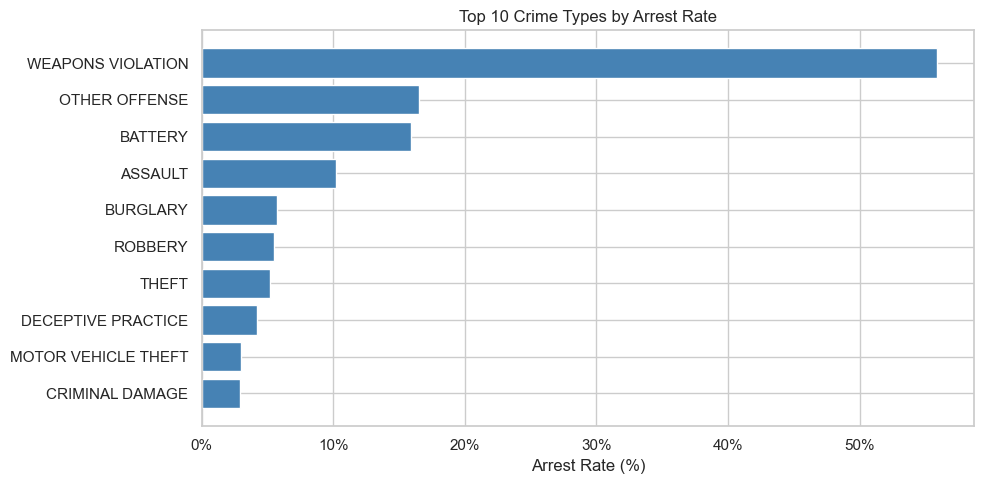

In [22]:
# Figure 1: top crime types by arrest rate
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = crime_type_rates.sort_values('arrest_rate_pct', ascending=True)
ax.barh(plot_df['crime_type'], plot_df['arrest_rate_pct'], color='steelblue')
ax.set_title('Top 10 Crime Types by Arrest Rate')
ax.set_xlabel('Arrest Rate (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

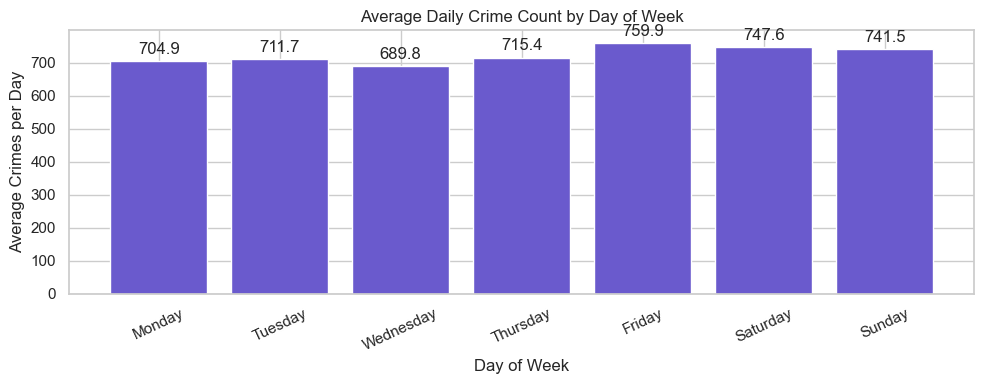

In [23]:
# Figure 2: daily crime counts by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_df = daily_crime.groupby('day_of_week', as_index=False)['crime_count'].mean()
dow_df['day_of_week'] = pd.Categorical(dow_df['day_of_week'], categories=day_order, ordered=True)
dow_df = dow_df.sort_values('day_of_week')

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(dow_df['day_of_week'], dow_df['crime_count'], color='slateblue')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_title('Average Daily Crime Count by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Crimes per Day')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

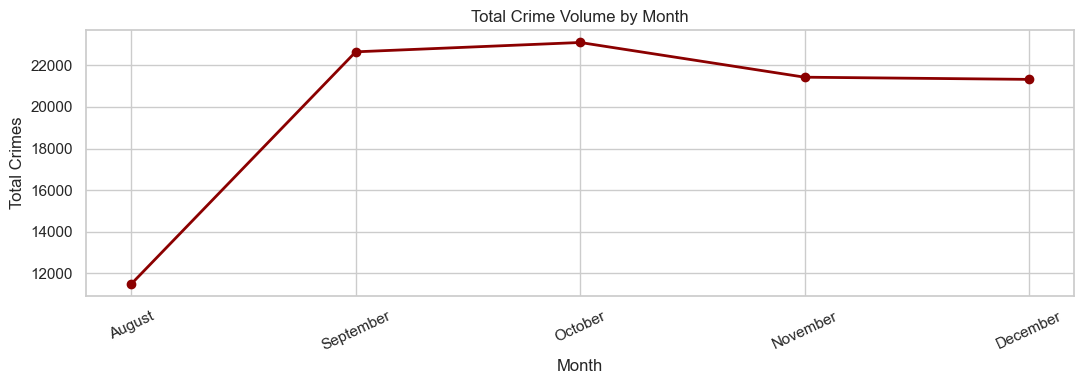

In [24]:
# Figure 3: monthly crime totals
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_df = daily_crime.groupby('month_name', as_index=False)['crime_count'].sum()
month_df['month_name'] = pd.Categorical(month_df['month_name'], categories=month_order, ordered=True)
month_df = month_df.sort_values('month_name')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(month_df['month_name'], month_df['crime_count'], marker='o', color='darkred', lw=2)
ax.set_title('Total Crime Volume by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Total Crimes')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

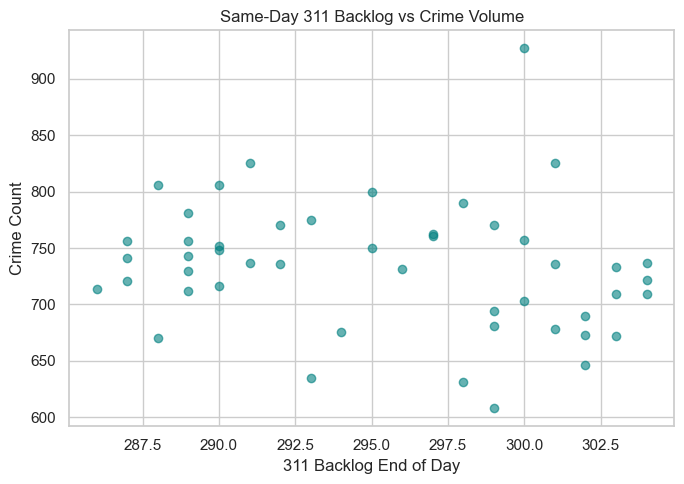

,crime_backlog_corr
0,-0.19532


In [25]:
# Figure 4: same-day crime count vs 311 backlog
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(crime_311_daily['backlog_end_of_day'], crime_311_daily['crime_count'], alpha=0.6, color='teal')
ax.set_title('Same-Day 311 Backlog vs Crime Volume')
ax.set_xlabel('311 Backlog End of Day')
ax.set_ylabel('Crime Count')
plt.tight_layout()
plt.show()

corr_df

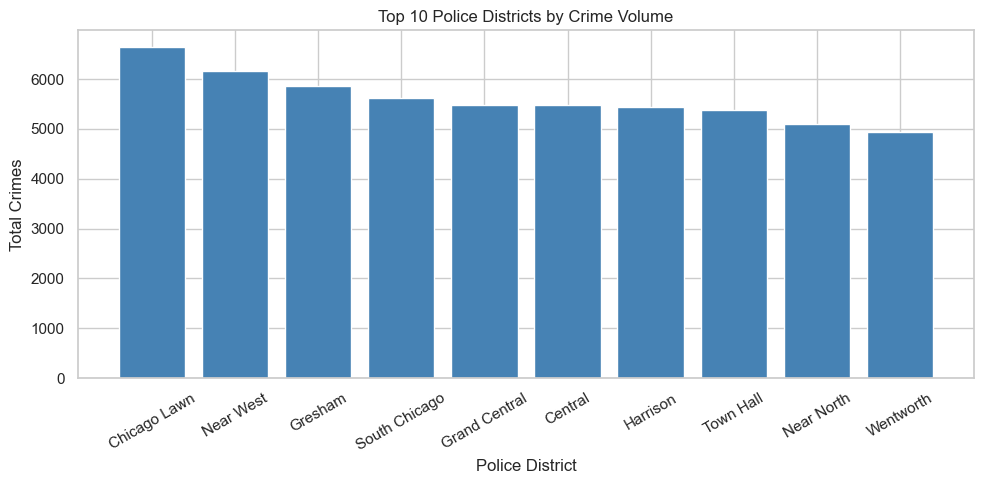

In [26]:
# Figure 5: district crime concentration
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(district_concentration['district_name'], district_concentration['total_crimes'], color='steelblue')
ax.set_title('Top 10 Police Districts by Crime Volume')
ax.set_xlabel('Police District')
ax.set_ylabel('Total Crimes')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

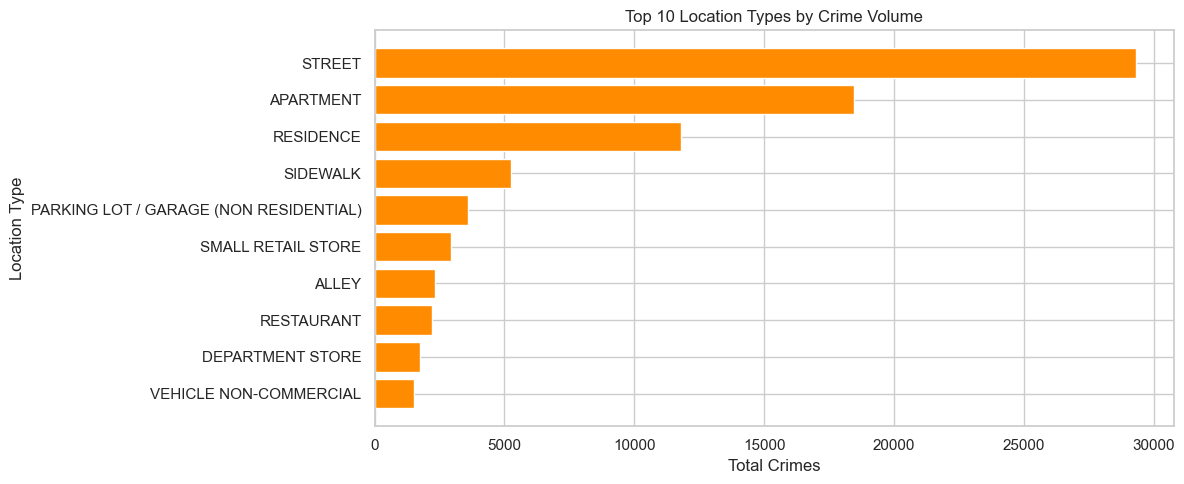

In [27]:
# Figure 6: location-type concentration
fig, ax = plt.subplots(figsize=(12, 5))
plot_loc = location_concentration.sort_values('total_crimes', ascending=True)
ax.barh(plot_loc['location_desc'], plot_loc['total_crimes'], color='darkorange')
ax.set_title('Top 10 Location Types by Crime Volume')
ax.set_xlabel('Total Crimes')
ax.set_ylabel('Location Type')
plt.tight_layout()
plt.show()

## Section 6 - Reproducibility Log

In [28]:
con.execute('SELECT * FROM run_manifest ORDER BY run_id DESC').df()

,run_id,run_ts,raw_crimes_rows,stg_crimes_rows,raw_311_rows,stg_311_rows,fact_crime_rows,fact_311_req_rows,fact_311_daily_rows,notes
0,3,2026-03-10 20:42:22.220677,100000,100000,50000,50000,100000,50000,2200,Automated build via build.py (crimes + 311)
1,2,2026-03-10 20:42:00.229797,100000,100000,50000,50000,100000,50000,2200,Automated build via build.py (crimes + 311)
2,1,2026-03-10 19:26:46.274057,100000,100000,<NA>,<NA>,100000,<NA>,<NA>,Automated build via build.py


## Section 7 - Summary and Limitations

### What this project demonstrates

- A one-command rebuild with `build.py`
- audit-first raw-data validation
- pre-aggregate-then-join for same-day 311 backlog analysis
- normalized dimensions for crime type, district, and location type
- Parquet export and a small performance benchmark
- query-plan inspection with `EXPLAIN`

### Limitations

- The crime extract uses a 100K-row API pull for 2023 rather than the full year history.
- The 311 analysis depends on the chosen service-request extract and its schema.
- Same-day correlation does not imply causation.


In [29]:
con.close()
print('Done.')

Done.
